In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt


In [2]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']



In [3]:
path_kunming = 'data/data-section-6/kunming_districts.gpkg'
path_kunming_districts = 'data/data-section-6/kunming_5districts_utm48.gpkg'


In [4]:
kunming_gpd = gpd.read_file(path_kunming)
kunming_gpd
# kunming_gpd.plot(color='none',edgecolor='red')



,dt_adcode,dt_name,ct_adcode,ct_name,pr_adcode,pr_name,cn_adcode,cn_name,geometry
0,530102,五华区,530100,昆明市,530000,云南省,100000,中华人民共和国,"MULTIPOLYGON (((102.71331 25.13652, 102.71547 ..."
1,530103,盘龙区,530100,昆明市,530000,云南省,100000,中华人民共和国,"MULTIPOLYGON (((102.71668 25.04473, 102.71663 ..."
2,530111,官渡区,530100,昆明市,530000,云南省,100000,中华人民共和国,"MULTIPOLYGON (((102.71717 25.03341, 102.71792 ..."
3,530112,西山区,530100,昆明市,530000,云南省,100000,中华人民共和国,"MULTIPOLYGON (((102.50726 24.86019, 102.50689 ..."
4,530113,东川区,530100,昆明市,530000,云南省,100000,中华人民共和国,"MULTIPOLYGON (((102.8034 26.30291, 102.80537 2..."
5,530114,呈贡区,530100,昆明市,530000,云南省,100000,中华人民共和国,"MULTIPOLYGON (((102.85321 24.69792, 102.85168 ..."
6,530115,晋宁区,530100,昆明市,530000,云南省,100000,中华人民共和国,"MULTIPOLYGON (((102.73979 24.81731, 102.74137 ..."
7,530124,富民县,530100,昆明市,530000,云南省,100000,中华人民共和国,"MULTIPOLYGON (((102.63768 25.36767, 102.64085 ..."
8,530125,宜良县,530100,昆明市,530000,云南省,100000,中华人民共和国,"MULTIPOLYGON (((103.27379 25.25786, 103.27332 ..."
9,530126,石林彝族自治县,530100,昆明市,530000,云南省,100000,中华人民共和国,"MULTIPOLYGON (((103.66655 24.7242, 103.66542 2..."


In [5]:
kunming_5districts_gpd = kunming_gpd[kunming_gpd['dt_name'].isin(['五华区', '盘龙区', '官渡区', '西山区', '呈贡区'])]
kunming_5districts_gpd


,dt_adcode,dt_name,ct_adcode,ct_name,pr_adcode,pr_name,cn_adcode,cn_name,geometry
0,530102,五华区,530100,昆明市,530000,云南省,100000,中华人民共和国,"MULTIPOLYGON (((102.71331 25.13652, 102.71547 ..."
1,530103,盘龙区,530100,昆明市,530000,云南省,100000,中华人民共和国,"MULTIPOLYGON (((102.71668 25.04473, 102.71663 ..."
2,530111,官渡区,530100,昆明市,530000,云南省,100000,中华人民共和国,"MULTIPOLYGON (((102.71717 25.03341, 102.71792 ..."
3,530112,西山区,530100,昆明市,530000,云南省,100000,中华人民共和国,"MULTIPOLYGON (((102.50726 24.86019, 102.50689 ..."
5,530114,呈贡区,530100,昆明市,530000,云南省,100000,中华人民共和国,"MULTIPOLYGON (((102.85321 24.69792, 102.85168 ..."


In [6]:
kunming_5districts_utm48_gpd = kunming_5districts_gpd.to_crs(epsg=32648)
area_districts = kunming_5districts_utm48_gpd.area/1000000
area_districts


0    388.681330
1    864.295297
2    638.333617
3    887.075812
5    499.363964
dtype: float64

Text(0, 0.5, '面积（km2）')

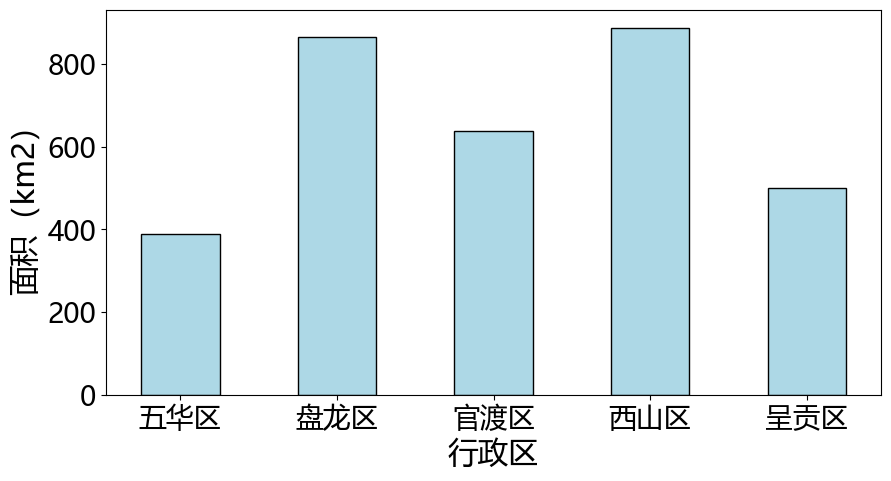

In [7]:

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(
    x=kunming_5districts_utm48_gpd['dt_name'],
    height=area_districts,
    facecolor='lightblue',
    edgecolor='black',
    width=0.5

)
ax.tick_params(axis='both', labelsize=20)
ax.set_xlabel('行政区', fontsize=22)
ax.set_ylabel('面积（km2）', fontsize=22)



In [8]:
# kunming_5districts_utm48_gpd.to_file(path_kunming_districts, driver='GPKG')



In [9]:
import rasterio as rio


In [10]:
path_lclu_2017 = 'data/data-section-6/48R_20170101-20180101.tif'
path_lclu_2024 = 'data/data-section-6/48R_20240101-20241231.tif'
path_lclu_2017_clip = 'data/data-section-6/48R_20170101-20180101_clip.tif'
path_lclu_2024_clip = 'data/data-section-6/48R_20240101-20241231_clip.tif'


In [11]:
lclu_2017_src = rio.open(path_lclu_2017)
lclu_2017_src.meta


{'driver': 'GTiff',
 'dtype': 'uint8',
 'nodata': 0.0,
 'width': 61044,
 'height': 89013,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 48N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",105],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'),
 'transform': Affine(10.0, 0.0, 194780.0,
        0.0, -10.0, 3544360.0)}

In [ ]:
# lclu_2017_arr = lclu_2017_src.read(1)
# lclu_2017_arr.shape


(89013, 61044)

In [13]:
# plt.imshow(lclu_2017_arr)


In [14]:
from rasterio.mask import mask

lclu_2017_clip_data, lclu_2017_clip_transform = mask(
    dataset=lclu_2017_src,
    shapes = list(kunming_5districts_utm48_gpd.geometry),
    crop = True,
    all_touched = False
)


In [15]:
lclu_2017_clip_data.shape


(1, 8423, 7026)

In [16]:
clip_meta = lclu_2017_src.meta.copy()
clip_meta.update({
    'height':lclu_2017_clip_data.shape[1],
    'width':lclu_2017_clip_data.shape[2],
    'transform':lclu_2017_clip_transform
})


In [17]:
with rio.open(
    fp=path_lclu_2017_clip,
    mode='w',
    driver=clip_meta['driver'],
    height=clip_meta['height'],
    width=clip_meta['width'],
    count=clip_meta['count'],
    dtype=clip_meta['dtype'],
    crs=clip_meta['crs'],
    transform=clip_meta['transform']) as dst:
    dst.write(lclu_2017_clip_data)



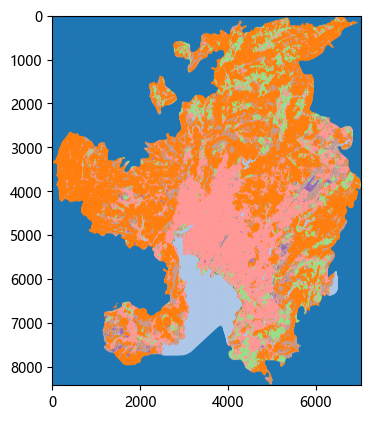

In [ ]:
plt.imshow(lclu_2017_clip_data[0], cmap='tab20', vmin=0, vmax=20)
